In [4]:
import os, gc, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix
from methylbert.data.vocab import MethylVocab
from methylbert.data.dataset import MethylBertFinetuneDataset
from methylbert.trainer import MethylBertFinetuneTrainer

DATA_DIR = "/home/bauerste/finetuneDatasets/dmr100"
FT_BASE  = "/home/bauerste/methylbert_finetune/finetuned_models"
SEQ_LEN, BATCH, NUM_WORKERS = 511, 32, 4

# (label, dir)
MODELS = []
for seed in (42, 67, 123):
    for variant in ("w_methylation", "wo_methylation"):
        MODELS.append((f"s{seed}_{variant}",
                       os.path.join(FT_BASE, f"finetune_out_s{seed}_{variant}")))

tokenizer = MethylVocab(3)
train_dataset = MethylBertFinetuneDataset(os.path.join(DATA_DIR, "train_seq.csv"), tokenizer, seq_len=SEQ_LEN)
eval_dataset  = MethylBertFinetuneDataset(os.path.join(DATA_DIR, "test_seq.csv"),  tokenizer, seq_len=SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH, num_workers=NUM_WORKERS)
eval_loader  = DataLoader(eval_dataset,  batch_size=BATCH, num_workers=NUM_WORKERS)
N_DMRS = train_dataset.num_dmrs()
print("num_dmrs:", N_DMRS, "| eval windows:", len(eval_dataset))

Building Vocab
Total number of sequences :  9283
# of reads in each label:  [4702. 4581.]
Total number of sequences :  1646
# of reads in each label:  [843. 803.]
num_dmrs: 100 | eval windows: 1646


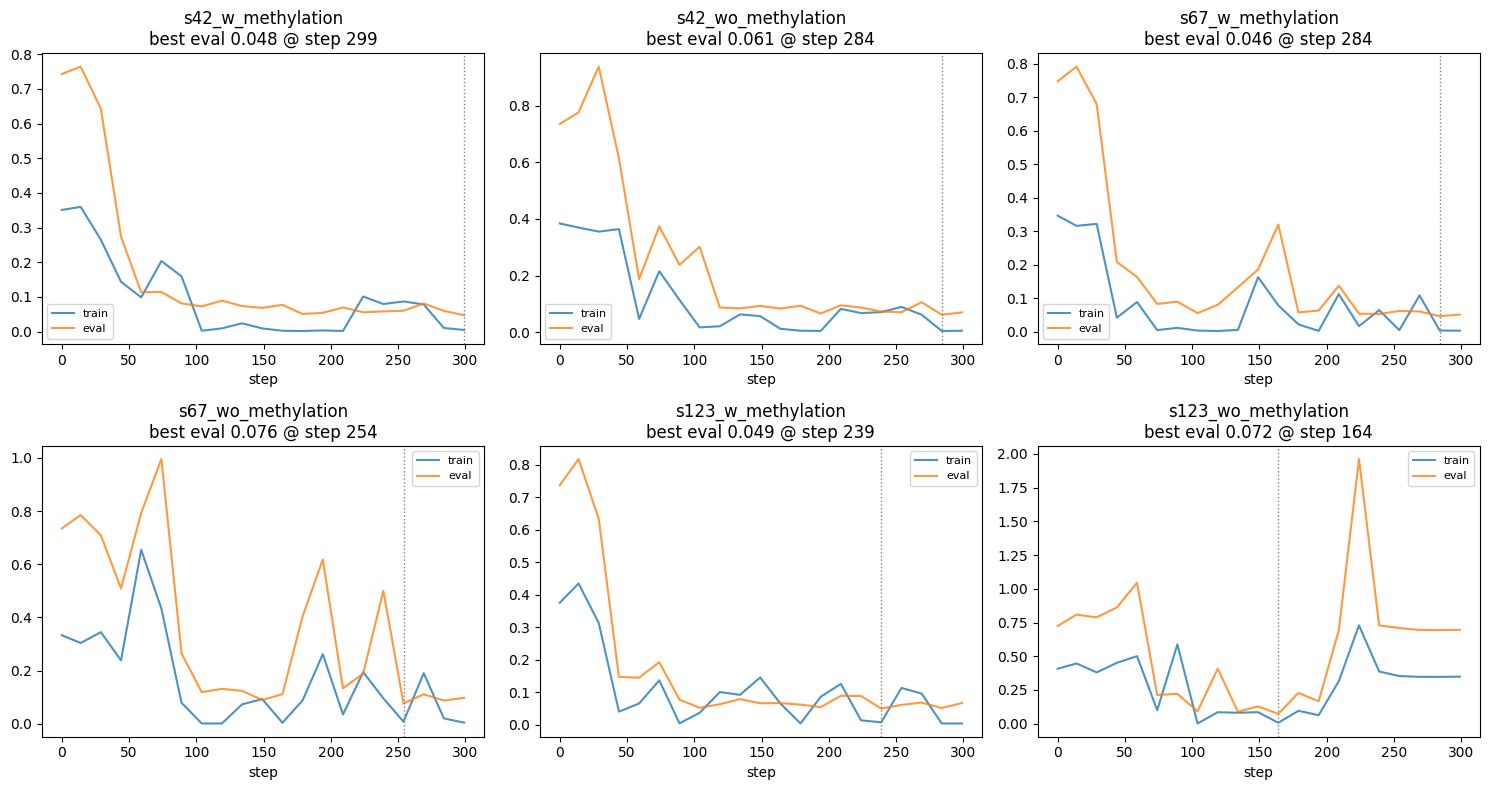

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (label, d) in zip(axes.flat, MODELS):
    try:
        dt = pd.read_csv(os.path.join(d, "train.csv"), sep="\t")
        de = pd.read_csv(os.path.join(d, "eval.csv"),  sep="\t")
    except FileNotFoundError:
        ax.set_title(f"{label}\n(no logs found)"); continue
    ax.plot(dt["step"], dt["loss"], label="train", alpha=.8)
    ax.plot(de["step"], de["loss"], label="eval", alpha=.8)
    best = de.loc[de["loss"].idxmin()]
    ax.axvline(best["step"], color="grey", ls=":", lw=1)
    ax.set_title(f"{label}\nbest eval {best['loss']:.3f} @ step {int(best['step'])}")
    ax.set_xlabel("step"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
def evaluate(model_dir):
    trainer = MethylBertFinetuneTrainer(
        len(tokenizer), save_path=model_dir,
        train_dataloader=train_loader, test_dataloader=eval_loader,
        with_cuda=True, loss="bce",
    )
    trainer.load(model_dir, n_dmrs=N_DMRS, load_fine_tune=True)
    res, logits = trainer.read_classification(eval_loader, tokenizer, logit=True)

    z = logits - logits.max(axis=1, keepdims=True)
    prob1 = (np.exp(z) / np.exp(z).sum(axis=1, keepdims=True))[:, 1]
    y = res["ctype_label"].values.astype(int)

    win_auc = roc_auc_score(y, prob1)
    bacc = balanced_accuracy_score(y, res["pred"].values)
    df = pd.DataFrame({"dmr": res["dmr_label"].values, "y": y, "p": prob1})
    region = [roc_auc_score(g["y"], g["p"]) for _, g in df.groupby("dmr") if g["y"].nunique() == 2]

    del trainer; gc.collect(); torch.cuda.empty_cache()
    return win_auc, np.mean(region), bacc

rows = []
for label, d in MODELS:
    print(f"evaluating {label} ...", flush=True)
    wa, ra, ba = evaluate(d)
    rows.append({"model": label, "window_AUROC": round(wa, 4),
                 "region_AUROC": round(ra, 4), "bal_acc": round(ba, 4)})

results = pd.DataFrame(rows)
print(results.to_string(index=False))

evaluating s42_w_methylation ...
The model is loaded on GPU
Restore the pretrained model /home/bauerste/methylbert_finetune/finetuned_models/finetune_out_s42_w_methylation
Cross entropy loss assigned
/home/bauerste/methylbert_finetune/finetuned_models/dmr_encoder.pickle is not found.
/home/bauerste/methylbert_finetune/finetuned_models/read_classification_model.pickle is not found.


/home/bauerste/methylbert_finetune/methylbert/src/methylbert/network.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.dmr_encoder.load_state_dict(torch.load(pretrai

Total Parameters: 287738370


  0%|          | 0/52 [00:00<?, ?it/s]

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


...

  0%|          | 0/52 [00:00<?, ?it/s]

evaluating s123_wo_methylation ...
The model is loaded on GPU
Restore the pretrained model /home/bauerste/methylbert_finetune/finetuned_models/finetune_out_s123_wo_methylation
Cross entropy loss assigned
/home/bauerste/methylbert_finetune/finetuned_models/dmr_encoder.pickle is not found.
/home/bauerste/methylbert_finetune/finetuned_models/read_classification_model.pickle is not found.
Total Parameters: 287738370


/home/bauerste/methylbert_finetune/methylbert/src/methylbert/network.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.dmr_encoder.load_state_dict(torch.load(pretrai

  0%|          | 0/52 [00:00<?, ?it/s]

              model  window_AUROC  region_AUROC  bal_acc
  s42_w_methylation        0.9963        0.9965   0.9908
 s42_wo_methylation        0.9924        0.9932   0.9865
  s67_w_methylation        0.9943        0.9946   0.9914
 s67_wo_methylation        0.9914        0.9927   0.9836
 s123_w_methylation        0.9974        0.9966   0.9908
s123_wo_methylation        0.9946        0.9944   0.9866


### 1000 dmr mixed

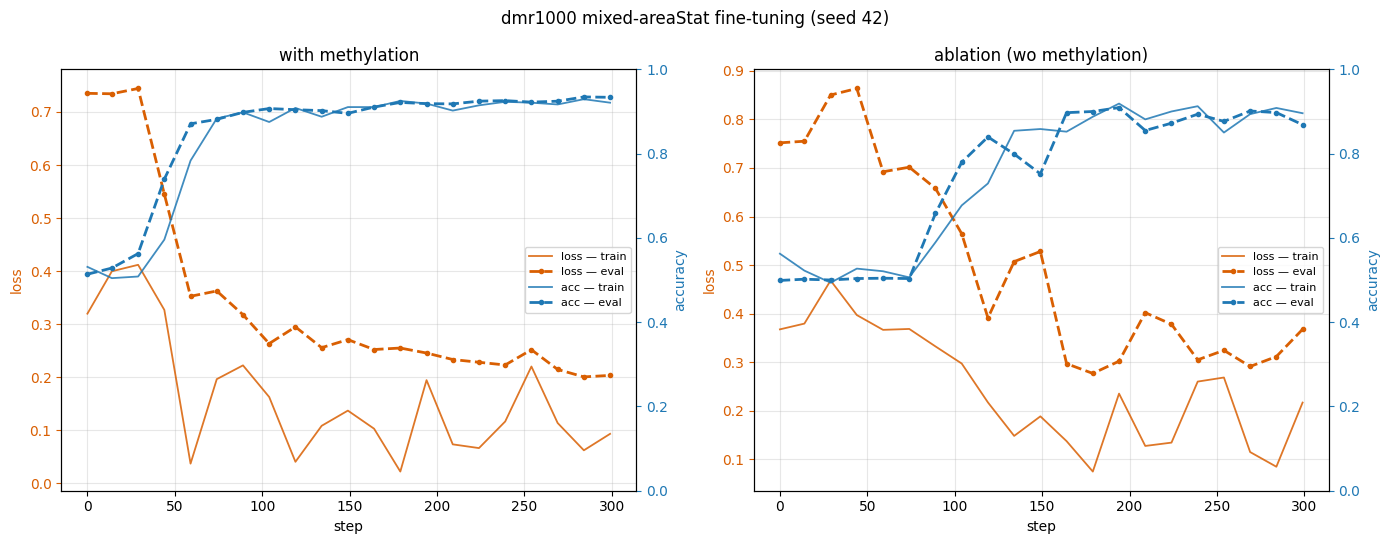

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/home/bauerste/methylbert_finetune/finetuned_models_mixed_dmr"
RUNS = {
    "with methylation":          f"{BASE}/finetune_out_dmr1000_s42_with_methylation",
    "ablation (wo methylation)": f"{BASE}/finetune_out_dmr1000_s42_wo_methylation",
}
LOSS_C, ACC_C = "#d95f02", "#1f78b4"

def load(path, cols):
    df = pd.read_csv(path, sep="\t")
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=cols).sort_values("step")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

for ax, (name, d) in zip(axes, RUNS.items()):
    tp, ep = os.path.join(d, "train.csv"), os.path.join(d, "eval.csv")
    if not os.path.exists(tp):
        ax.set_title(f"{name}\n[no train.csv]"); continue
    tr = load(tp, ["step", "loss", "ctype_acc"])
    ev = load(ep, ["step", "ctype_acc", "loss"])

    ax2 = ax.twinx()
    l1, = ax.plot(tr.step,  tr.loss,      color=LOSS_C, lw=1.3, alpha=.85,               label="loss — train")
    l2, = ax.plot(ev.step,  ev.loss,      color=LOSS_C, lw=2, ls="--", marker="o", ms=3, label="loss — eval")
    l3, = ax2.plot(tr.step, tr.ctype_acc, color=ACC_C,  lw=1.3, alpha=.85,               label="acc — train")
    l4, = ax2.plot(ev.step, ev.ctype_acc, color=ACC_C,  lw=2, ls="--", marker="o", ms=3, label="acc — eval")

    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("loss", color=LOSS_C)
    ax2.set_ylabel("accuracy", color=ACC_C)
    ax.tick_params(axis="y", colors=LOSS_C)
    ax2.tick_params(axis="y", colors=ACC_C)
    ax2.set_ylim(0, 1)
    ax.grid(alpha=.3)
    ax.legend(handles=[l1, l2, l3, l4], fontsize=8, loc="center right")

fig.suptitle("dmr1000 mixed-areaStat fine-tuning (seed 42)")
fig.tight_layout()
plt.show()

In [1]:
import os, sys
sys.path.insert(0, os.path.expanduser("~/methylbert_finetune/methylbert/myNotebooks"))
from baseline_two_means import compute_baseline

HOME = os.path.expanduser("~")
BASE_TRAIN = os.path.join(HOME, "finetuneDatasetsMixedDMR/dmr1000/train_seq.csv")
BASE_TEST  = os.path.join(HOME, "finetuneTestdataMixedDMR/dmr1000_test/data.csv")

b = compute_baseline(BASE_TRAIN, BASE_TEST, verbose=False)
print("two-means baseline (mixed dmr1000):")
print(f"  AUROC         {b['auroc']:.4f}")
print(f"  accuracy      {b['accuracy']:.4f}")
print(f"  bal. accuracy {b['balanced_accuracy']:.4f}")

two-means baseline (mixed dmr1000):
  AUROC         0.9818
  accuracy      0.9529
  bal. accuracy 0.9529
